In [9]:
import sys, os
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_selector import Data_selector
from feature_adder import Feature_adder
from feature_selector import Feature_selector
from logs.logger import CustomLogger
from models import Random_Forest, Linear, Polynomial, XGBoost, LinearL1
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

logger = CustomLogger(name="model_main", log_file_name='model_main.log').get_logger()
from main import *

In [105]:
write_predictions = False

number_mimo = 4
is_mimo = number_mimo > 1
y_is_flat = not is_mimo

l_min = 4
max_diff = 4
c_thresh = 0.9

df = add_features_and_filter(l_min, max_diff, c_thresh, read_from_integrated=False)
logger.info(f"Csv file has bean labeled successfully")

ds = Data_selector(df)
df_modified = ds.select_peaks(goodness=3)
logger.info(f"Rows have been selected successfully")

X, y = select_features_and_get_X_and_y(df_modified,is_mimo=is_mimo,number_mimo=number_mimo)
logger.info(f"Some features have been dropped successfully")

rr = [22101, 29656,  4871, 18532, 43270, 39330, 20634,  1599, 41376,
       14608, 21884,  9354,  5258, 24489, 40823, 38379, 30405, 11544,
       28572, 11416, 34216, 39216, 30339,  7386, 30324, 44262, 22073,
       13938,  7839, 28375, 42970, 37287, 44683, 21985, 10326, 41772,
        8013, 26180, 41547, 31931, 31543, 28562, 32209]
X = X.drop(rr)
y = y.drop(rr)

# model = Random_Forest(n_estimators=100, max_depth=20)
# model = Linear()
# model = Polynomial(degree=2)
# model = XGBoost(n_estimators=1000, max_depth=5)
# model = Neural_network(input_dim=X.shape[1], epochs=100, verbose=1)

model = XGBoost(n_estimators=1000, max_depth=5)
model.scale_and_split_data(X, y,y_is_flat=y_is_flat)
model.fit()
logger.info(f"Model has been trained successfully")

test_model(model)

if write_predictions:
    write_result(df, model, X)


2025-09-15 16:13:36 - model_main - INFO - Csv file has bean labeled successfully
2025-09-15 16:13:36 - model_main - INFO - Rows have been selected successfully
2025-09-15 16:13:40 - model_main - INFO - Some features have been dropped successfully


(56759, 55) (56759, 4)
False
(56759, 55) (56759, 4)
(56759, 55) (56759, 4)


2025-09-15 16:13:48 - model_main - INFO - Model has been trained successfully
2025-09-15 16:13:48 - model_main - INFO - Train Error: 1.54%, Test Error: 2.10%


In [102]:
y_pred_test = model.model.predict(model.X_test)
y_pred_train = model.model.predict(model.X_train)

y_pred_test_actual  = model.inverse_scale_array(model.scaler_y, y_pred_test)
y_pred_train_actual = model.inverse_scale_array(model.scaler_y, y_pred_train)
y_test_actual       = model.inverse_scale_array(model.scaler_y, model.y_test)
y_train_actual      = model.inverse_scale_array(model.scaler_y, model.y_train)

In [103]:
y_diff = y_pred_train_actual - y_train_actual

In [104]:
y_diff1 = np.linalg.norm(y_diff, axis=1)/np.linalg.norm(y_train_actual, axis=1)
ar = np.argsort(y_diff1)
y_hist = y_diff1[ar]

In [96]:
ar[-43:]

array([  712, 43997, 28083, 13788, 14983, 44231, 42725,   875,  4443,
       27000, 44709, 20902, 27327,  1763, 45174, 13010, 23368,  1090,
       29692, 45212, 38811,  7994, 32633,  2868, 42116, 10501,  9847,
       26400, 10197, 31704, 37525, 19802,  7369,  7850, 40830, 28355,
       32726, 11518, 36221, 40596, 12496, 18329, 29733], dtype=int64)

In [97]:
np.count_nonzero(y_hist<0.04)

44554

In [98]:
len(y_hist)

45407

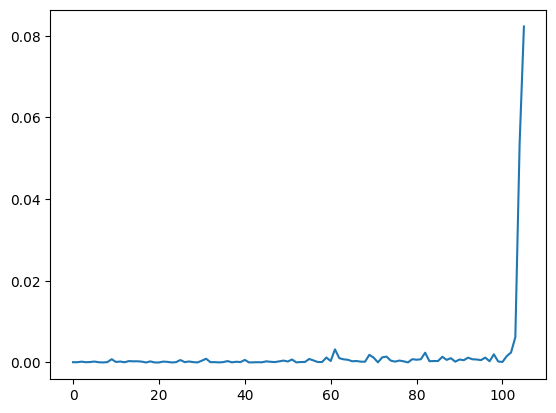

In [100]:
plt.plot(np.diff(y_hist)[45300:45408])

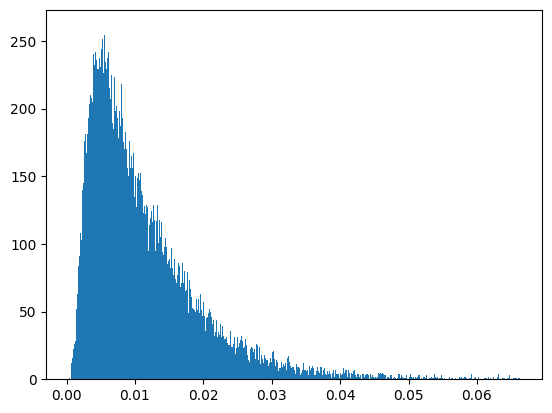

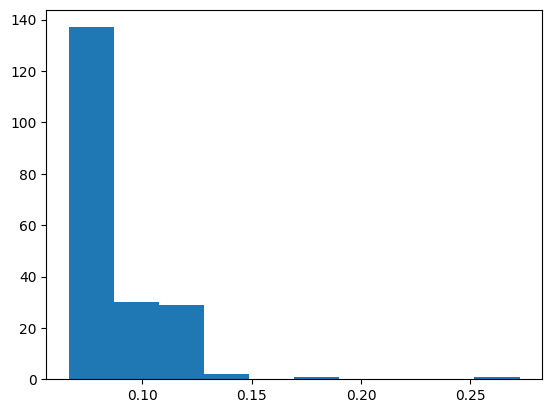

In [82]:
_ = plt.hist(y_hist[:-200],bins=1000)
plt.show()
_ = plt.hist(y_hist[-200:],bins=10)